<a href="https://colab.research.google.com/github/hiratafelipe/m1_pt2_processamento_imagens/blob/main/m1_pt2_processamento_imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 01 — Bibliotecas e parâmetros do experimento
# Execute as células em ordem. No Colab, as bibliotecas abaixo já estão disponíveis.

from functools import lru_cache
from pathlib import Path
import hashlib
import json
import shutil
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

BASE_PADRAO = (
    Path("/content/projeto_m1")
    if Path("/content").exists()
    else Path.cwd() / "projeto_m1"
)
BASE = Path(globals().get("PASTA_PROJETO", BASE_PADRAO))
ORIGINAIS = BASE / "imagens" / "originais"
CINZA = BASE / "imagens" / "cinza"
RUIDO = BASE / "imagens" / "ruido"
PROCESSADAS = BASE / "imagens" / "processadas"
RESULTADOS = BASE / "resultados"
DOCUMENTACAO = BASE / "documentacao"

# A e B recebem os mesmos pixels degradados; apenas a janela da mediana muda.
PROPORCAO_RUIDO = 0.05
SEMENTES_RUIDO = {
    "ISIC_0000013": 20260924,
    "ISIC_0000029": 20260925,
    "ISIC_0000049": 20260926,
}
CONFIGURACOES = {
    "A": {
        "gama": 0.9,
        "mediana": 3,
        "k": 1.2,
        "gauss_tamanho": 5,
        "gauss_sigma": 1.0,
    },
    "B": {
        "gama": 0.9,
        "mediana": 5,
        "k": 1.2,
        "gauss_tamanho": 5,
        "gauss_sigma": 1.0,
    },
}

JANELA_SSIM = 11
SIGMA_SSIM = 1.5
K1_SSIM = 0.01
K2_SSIM = 0.03
TAMANHO_RECORTE = 200
FAIXA_BORDA = 5

# Ative apenas se desejar gerar o ZIP no fim da execução.
EXPORTAR_BACKUP = False


In [ ]:
# 02 — Imagens selecionadas e suas fontes
# Melanomas do tronco posterior, com diferenças de intensidade e textura.
# Os hashes identificam os JPEGs usados no experimento original.

IMAGENS = [
    {
        "id": "ISIC_0000013",
        "pagina": "https://api.isic-archive.com/images/ISIC_0000013/",
        "url": "https://isic-archive.s3.amazonaws.com/images/ISIC_0000013.jpg",
        "diagnostico": "Melanoma Invasive",
        "categoria": "Melanoma",
        "regiao": "Posterior trunk",
        "confirmacao": "histopathology",
        "largura": 1022,
        "altura": 767,
        "licenca": "CC-0",
        "atribuicao": "Anonymous",
        "consulta": "2026-09-21",
        "sha256": "087a955305a31cf5c6d197c9aa8848bb23822201b656d47f89fe4020a4b78650",
        "observacao_visual": "Região central muito escura em relação à pele ao redor; "
        "detalhes internos pouco distinguíveis nessa área. Útil para "
        "estudar a transformação de intensidade e o risco de perder "
        "detalhes na suavização.",
    },
    {
        "id": "ISIC_0000029",
        "pagina": "https://api.isic-archive.com/images/ISIC_0000029/",
        "url": "https://isic-archive.s3.amazonaws.com/images/ISIC_0000029.jpg",
        "diagnostico": "Melanoma, NOS",
        "categoria": "Melanoma",
        "regiao": "Posterior trunk",
        "confirmacao": "histopathology",
        "largura": 1504,
        "altura": 1129,
        "licenca": "CC-0",
        "atribuicao": "Anonymous",
        "consulta": "2026-09-21",
        "sha256": "3a58d19e7073ebaf74482e92dc2a4fa5e21699308829b0a0e6d583863c2414ee",
        "observacao_visual": "Variação de intensidade dentro da lesão, com áreas escuras e "
        "uma área central mais clara. Há pelos atravessando a imagem e "
        "um pequeno artefato circular à direita. Útil para avaliar "
        "preservação de detalhes e realce indesejado de artefatos.",
    },
    {
        "id": "ISIC_0000049",
        "pagina": "https://api.isic-archive.com/images/ISIC_0000049/",
        "url": "https://isic-archive.s3.amazonaws.com/images/ISIC_0000049.jpg",
        "diagnostico": "Melanoma in situ",
        "categoria": "Melanoma",
        "regiao": "Posterior trunk",
        "confirmacao": "histopathology",
        "largura": 1504,
        "altura": 1129,
        "licenca": "CC-0",
        "atribuicao": "Anonymous",
        "consulta": "2026-09-21",
        "sha256": "da80630e8d89ba455522cb109229c95f1b8371bd96751924a8b452ea14539ca2",
        "observacao_visual": "Áreas claras com transições suaves para a pele e uma região "
        "mais escura na parte inferior direita. Útil para estudar "
        "contraste local e o risco de a suavização apagar estruturas "
        "tênues.",
    },
]


In [ ]:
# 03 — Validação, salvamento e comparação visual


def validar_imagem(imagem, exigir_faixa=True):
    """Converte para float64 e verifica se a imagem é uma matriz válida."""
    matriz = np.asarray(imagem, dtype=np.float64)
    if matriz.ndim != 2 or matriz.size == 0 or not np.isfinite(matriz).all():
        raise ValueError("Esperada uma matriz 2D não vazia com valores finitos.")
    if exigir_faixa and (matriz.min() < 0 or matriz.max() > 255):
        raise ValueError("As intensidades devem estar entre 0 e 255.")
    return matriz


def validar_tamanho(tamanho):
    if not isinstance(tamanho, (int, np.integer)) or tamanho < 1 or tamanho % 2 == 0:
        raise ValueError("A janela deve ter tamanho inteiro, positivo e ímpar.")


def para_uint8(imagem):
    # Limitação e arredondamento ocorrem apenas nas saídas, não entre os filtros.
    matriz = validar_imagem(imagem, exigir_faixa=False)
    return np.rint(np.clip(matriz, 0, 255)).astype(np.uint8)


def salvar_json(caminho, dados):
    caminho = Path(caminho)
    caminho.parent.mkdir(parents=True, exist_ok=True)
    caminho.write_text(
        json.dumps(dados, ensure_ascii=False, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def salvar_cinza(imagem, caminho):
    """Salva uma cópia PNG; a matriz usada no processamento não é alterada."""
    caminho = Path(caminho)
    caminho.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(para_uint8(imagem)).save(caminho)


def salvar_figura(figura, caminho):
    caminho = Path(caminho)
    caminho.parent.mkdir(parents=True, exist_ok=True)
    figura.savefig(caminho, dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(figura)


def recorte_central(imagem, tamanho=TAMANHO_RECORTE):
    # Imagens pequenas também são aceitas; o recorte nunca começa em índice negativo.
    altura, largura = imagem.shape[:2]
    y = max(0, (altura - tamanho) // 2)
    x = max(0, (largura - tamanho) // 2)
    return slice(y, y + tamanho), slice(x, x + tamanho)


def exibir_comparacao(matrizes, titulos, titulo, destino, recorte=None):
    if not matrizes or len(matrizes) != len(titulos):
        raise ValueError("Informe uma legenda para cada imagem.")
    figura, eixos = plt.subplots(
        1,
        len(matrizes),
        figsize=(4 * len(matrizes), 4.5),
        layout="constrained",
        squeeze=False,
    )
    for eixo, matriz, legenda in zip(eixos[0], matrizes, titulos):
        exibida = matriz if recorte is None else matriz[recorte]
        # A mesma escala evita que a exibição altere o contraste de cada painel.
        eixo.imshow(exibida, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        eixo.set_title(legenda)
        eixo.axis("off")
    figura.suptitle(titulo)
    salvar_figura(figura, destino)


In [ ]:
# 04 — Leitura das imagens, conversão para cinza e histograma


def baixar_original(item):
    caminho = ORIGINAIS / f"{item['id']}.jpg"
    if caminho.exists():
        conteudo = caminho.read_bytes()
    else:
        with urllib.request.urlopen(item["url"], timeout=60) as resposta:
            conteudo = resposta.read()

    if hashlib.sha256(conteudo).hexdigest() != item["sha256"]:
        raise ValueError(f"O arquivo difere do original registrado: {item['id']}")
    if not caminho.exists():
        caminho.parent.mkdir(parents=True, exist_ok=True)
        caminho.write_bytes(conteudo)
    return caminho


def carregar_rgb(caminho):
    with Image.open(caminho) as imagem:
        return np.array(imagem.convert("RGB"), dtype=np.uint8)


def rgb_para_cinza(rgb):
    if rgb.ndim != 3 or rgb.shape[2] != 3:
        raise ValueError("Esperada uma matriz RGB com três canais.")
    canais = rgb.astype(np.float64)
    # Pillow fornece RGB. Os pesos seguem essa ordem, conforme a aula.
    intensidade = (
        0.299 * canais[:, :, 0] + 0.587 * canais[:, :, 1] + 0.114 * canais[:, :, 2]
    )
    return para_uint8(intensidade)


def calcular_histograma(imagem):
    if imagem.ndim != 2 or imagem.dtype != np.uint8 or imagem.size == 0:
        raise ValueError("Use uma imagem em cinza não vazia do tipo uint8.")
    contagens = np.zeros(256, dtype=np.int64)
    # Contagem explícita, sem chamar uma função pronta de histograma.
    for pixel in imagem.flat:
        contagens[int(pixel)] += 1
    return contagens


In [ ]:
# 05 — Ruído sal e pimenta e transformação gama


def adicionar_sal_pimenta(imagem, proporcao, semente):
    if imagem.ndim != 2 or imagem.dtype != np.uint8 or imagem.size == 0:
        raise ValueError("Use uma imagem em cinza não vazia do tipo uint8.")
    if not np.isfinite(proporcao) or not 0 <= proporcao <= 1:
        raise ValueError("A proporção deve estar entre 0 e 1.")
    if not isinstance(semente, (int, np.integer)) or semente < 0:
        raise ValueError("A semente deve ser um inteiro não negativo.")

    saida = imagem.copy()
    mascara = np.zeros(imagem.shape, dtype=np.uint8)
    quantidade = round(proporcao * imagem.size)
    gerador = np.random.Generator(np.random.PCG64(semente))

    # Sem reposição: cada posição é escolhida no máximo uma vez.
    posicoes = gerador.choice(imagem.size, size=quantidade, replace=False)
    pimenta = posicoes[: quantidade // 2]
    sal = posicoes[quantidade // 2 :]
    saida.flat[pimenta] = 0
    saida.flat[sal] = 255
    mascara.flat[pimenta] = 1
    mascara.flat[sal] = 2
    return saida, mascara


def correcao_gama(imagem, gama):
    matriz = validar_imagem(imagem)
    if not np.isfinite(gama) or gama <= 0:
        raise ValueError("Gama deve ser finito e positivo.")
    # Gama < 1 clareia os tons intermediários; 0 e 255 permanecem nos extremos.
    return 255.0 * (matriz / 255.0) ** gama


In [ ]:
# 06 — Tratamento das bordas e filtro da mediana


def expandir_bordas(imagem, raio_y, raio_x=None):
    """Repete os pixels extremos por indexação."""
    matriz = validar_imagem(imagem, exigir_faixa=False)
    raio_x = raio_y if raio_x is None else raio_x
    if any(
        not isinstance(raio, (int, np.integer)) or raio < 0 for raio in (raio_y, raio_x)
    ):
        raise ValueError("Os raios devem ser inteiros não negativos.")
    altura, largura = matriz.shape
    linhas = np.clip(np.arange(-raio_y, altura + raio_y), 0, altura - 1)
    colunas = np.clip(np.arange(-raio_x, largura + raio_x), 0, largura - 1)
    return matriz[linhas[:, None], colunas[None, :]]


def filtro_mediana(imagem, tamanho=3):
    matriz = validar_imagem(imagem)
    validar_tamanho(tamanho)
    altura, largura = matriz.shape
    expandida = expandir_bordas(matriz, tamanho // 2)
    saida = np.empty_like(matriz)

    # Blocos de 64 linhas limitam a memória sem interromper as vizinhanças.
    for inicio in range(0, altura, 64):
        fim = min(inicio + 64, altura)
        vizinhos = np.stack(
            [
                expandida[inicio + dy : fim + dy, dx : dx + largura]
                for dy in range(tamanho)
                for dx in range(tamanho)
            ],
            axis=-1,
        )
        # A mediana é o elemento central após ordenar a vizinhança.
        vizinhos.sort(axis=-1)
        saida[inicio:fim] = vizinhos[:, :, tamanho * tamanho // 2]
    return saida


In [ ]:
# 07 — Gaussiana, convolução e High-Boost


@lru_cache(maxsize=16)
def vetor_gaussiano(tamanho, sigma):
    """Calcula os pesos uma vez por combinação de tamanho e sigma."""
    validar_tamanho(tamanho)
    if not np.isfinite(sigma) or sigma <= 0:
        raise ValueError("Sigma deve ser finito e positivo.")
    coordenadas = np.arange(tamanho, dtype=np.float64) - tamanho // 2
    pesos = np.exp(-(coordenadas**2) / (2 * sigma**2))
    pesos /= pesos.sum()
    pesos.setflags(write=False)  # Protege os pesos compartilhados pelo cache.
    return pesos


def kernel_gaussiano(tamanho=5, sigma=1.0):
    pesos = vetor_gaussiano(tamanho, sigma)
    return pesos[:, None] * pesos[None, :]


def convolucao(imagem, kernel):
    matriz = validar_imagem(imagem, exigir_faixa=False)
    pesos = np.asarray(kernel, dtype=np.float64)
    if pesos.ndim != 2 or not np.isfinite(pesos).all():
        raise ValueError("O kernel deve ser uma matriz 2D finita.")
    ky, kx = pesos.shape
    validar_tamanho(ky)
    validar_tamanho(kx)
    expandida = expandir_bordas(matriz, ky // 2, kx // 2)
    invertido = pesos[::-1, ::-1]  # Rotação de 180°: convolução, não correlação.
    altura, largura = matriz.shape
    saida = np.zeros_like(matriz)
    for y in range(ky):
        for x in range(kx):
            saida += invertido[y, x] * expandida[y : y + altura, x : x + largura]
    return saida


def realce_highboost(imagem, k=1.2, tamanho=5, sigma=1.0):
    matriz = validar_imagem(imagem)
    if not np.isfinite(k) or k <= 1:
        raise ValueError("Use k > 1 para High-Boost, conforme a convenção da aula.")
    suavizada = convolucao(matriz, kernel_gaussiano(tamanho, sigma))
    mascara = matriz - suavizada
    bruta = matriz + k * mascara
    # A máscara pode ser negativa. A saída final combina detalhes e imagem completa.
    return {
        "suavizada": suavizada,
        "mascara": mascara,
        "bruta": bruta,
        "final": para_uint8(bruta),
        "recorte_abaixo": int(np.count_nonzero(bruta < 0)),
        "recorte_acima": int(np.count_nonzero(bruta > 255)),
    }


def executar_pipeline(
    imagem, gama=0.9, mediana=3, k=1.2, gauss_tamanho=5, gauss_sigma=1.0
):
    """Aplica gama, mediana e High-Boost sem quantização entre as etapas."""
    pontual = correcao_gama(imagem, gama)
    limpa = filtro_mediana(pontual, mediana)
    realce = realce_highboost(limpa, k, gauss_tamanho, gauss_sigma)
    return {"gama": pontual, "mediana": limpa, **realce}


In [ ]:
# 08 — PSNR e SSIM implementados explicitamente
# As métricas comparam cada resultado com a referência em cinza sem ruído.


def validar_par(referencia, saida):
    a = validar_imagem(referencia)
    b = validar_imagem(saida)
    if a.shape != b.shape:
        raise ValueError("As imagens devem ter as mesmas dimensões.")
    return a, b


def psnr(referencia, saida):
    a, b = validar_par(referencia, saida)
    # Subtrair em float64 evita overflow de uint8.
    mse = float(np.mean((a - b) ** 2))
    return float("inf") if mse == 0 else float(10 * np.log10(255.0**2 / mse))


def media_gaussiana_separavel(imagem, pesos):
    """Calcula a média local em duas passagens, aproveitando a separabilidade."""
    raio = len(pesos) // 2
    altura, largura = imagem.shape
    expandida_x = expandir_bordas(imagem, 0, raio)
    horizontal = np.zeros_like(imagem, dtype=np.float64)
    for x, peso in enumerate(pesos):
        horizontal += peso * expandida_x[:, x : x + largura]
    expandida_y = expandir_bordas(horizontal, raio, 0)
    resultado = np.zeros_like(imagem, dtype=np.float64)
    for y, peso in enumerate(pesos):
        resultado += peso * expandida_y[y : y + altura, :]
    return resultado


def estatisticas_locais(imagem, pesos):
    media = media_gaussiana_separavel(imagem, pesos)
    # O máximo com zero corrige apenas pequenos valores negativos de arredondamento.
    variancia = np.maximum(
        media_gaussiana_separavel(imagem * imagem, pesos) - media**2, 0
    )
    return media, variancia


def calcular_ssim(a, b, pesos, estatisticas_a, k1, k2):
    media_a, variancia_a = estatisticas_a
    media_b, variancia_b = estatisticas_locais(b, pesos)
    covariancia = media_gaussiana_separavel(a * b, pesos) - media_a * media_b
    c1, c2 = (k1 * 255) ** 2, (k2 * 255) ** 2
    mapa = (
        (2 * media_a * media_b + c1)
        * (2 * covariancia + c2)
        / ((media_a**2 + media_b**2 + c1) * (variancia_a + variancia_b + c2))
    )
    # Só janelas completas entram na média. Covariâncias negativas são preservadas.
    raio = len(pesos) // 2
    area_valida = mapa[raio:-raio, raio:-raio] if raio else mapa
    return float(np.mean(area_valida))


def ssim(referencia, saida, tamanho=11, sigma=1.5, k1=0.01, k2=0.03):
    a, b = validar_par(referencia, saida)
    validar_tamanho(tamanho)
    if min(a.shape) < tamanho:
        raise ValueError("A imagem deve comportar a janela do SSIM.")
    if not all(np.isfinite(k) and k > 0 for k in (k1, k2)):
        raise ValueError("K1 e K2 devem ser finitos e positivos.")
    pesos = vetor_gaussiano(tamanho, sigma)
    return calcular_ssim(a, b, pesos, estatisticas_locais(a, pesos), k1, k2)


def avaliar_resultados(referencia, candidatos):
    """Reutiliza as estatísticas da referência nas várias comparações SSIM."""
    a = validar_imagem(referencia)
    if min(a.shape) < JANELA_SSIM:
        raise ValueError(f"Use pelo menos {JANELA_SSIM} pixels em cada dimensão.")
    if not all(np.isfinite(k) and k > 0 for k in (K1_SSIM, K2_SSIM)):
        raise ValueError("K1 e K2 devem ser finitos e positivos.")
    pesos = vetor_gaussiano(JANELA_SSIM, SIGMA_SSIM)
    estatisticas_a = estatisticas_locais(a, pesos)
    medidas = []
    for etapa, matriz in candidatos.items():
        _, b = validar_par(a, matriz)
        valor_psnr = psnr(a, b)
        medidas.append(
            {
                "etapa": etapa,
                "psnr_db": None if np.isinf(valor_psnr) else valor_psnr,
                "psnr_infinito": bool(np.isinf(valor_psnr)),
                "ssim": calcular_ssim(a, b, pesos, estatisticas_a, K1_SSIM, K2_SSIM),
            }
        )
    return medidas


ISIC_0000013 | Melanoma Invasive | Posterior trunk | (767, 1022, 3)
Região central muito escura em relação à pele ao redor; detalhes internos pouco distinguíveis nessa área. Útil para estudar a transformação de intensidade e o risco de perder detalhes na suavização. 

ISIC_0000029 | Melanoma, NOS | Posterior trunk | (1129, 1504, 3)
Variação de intensidade dentro da lesão, com áreas escuras e uma área central mais clara. Há pelos atravessando a imagem e um pequeno artefato circular à direita. Útil para avaliar preservação de detalhes e realce indesejado de artefatos. 

ISIC_0000049 | Melanoma in situ | Posterior trunk | (1129, 1504, 3)
Áreas claras com transições suaves para a pele e uma região mais escura na parte inferior direita. Útil para estudar contraste local e o risco de a suavização apagar estruturas tênues. 



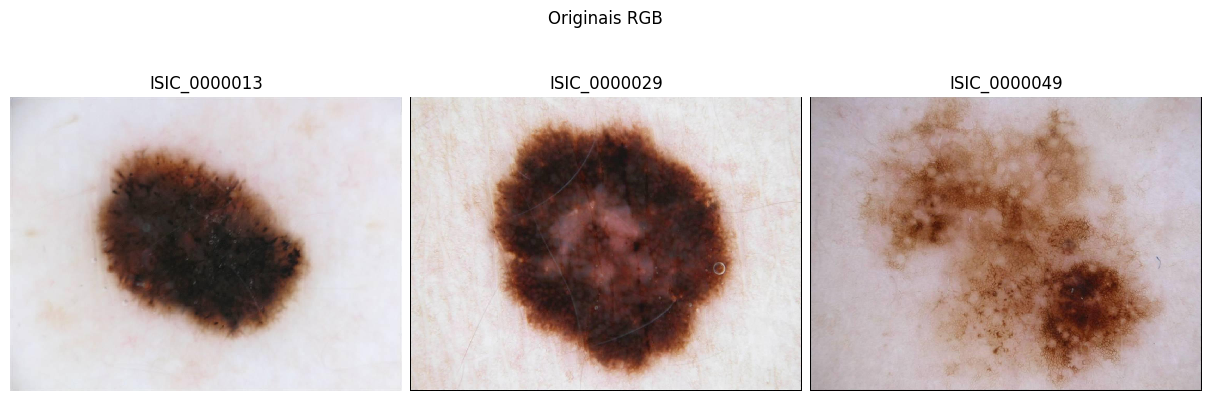

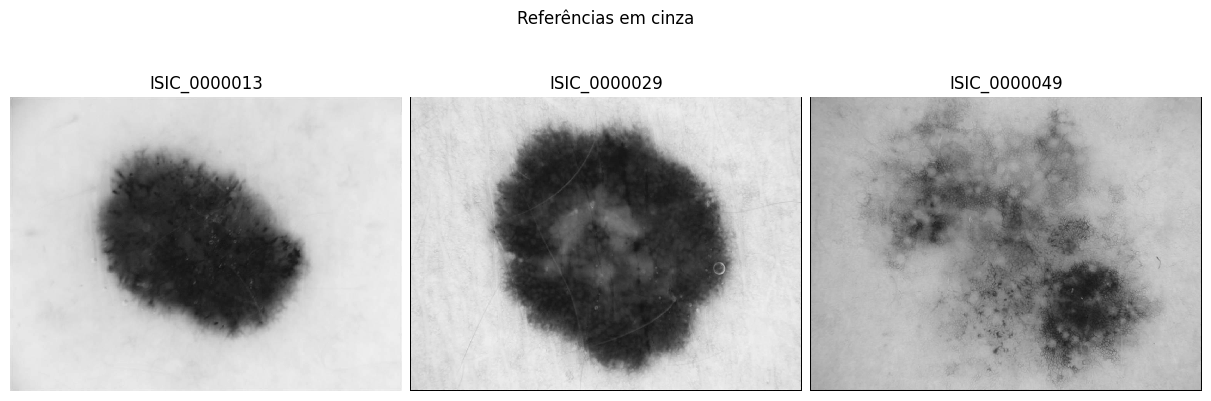

In [ ]:
# 09 — Preparação dos arquivos e caracterização inicial

for pasta in (ORIGINAIS, CINZA, RUIDO, PROCESSADAS, RESULTADOS, DOCUMENTACAO):
    pasta.mkdir(parents=True, exist_ok=True)

imagens_rgb = {}
imagens_cinza = {}
for item in IMAGENS:
    nome = item["id"]
    rgb = carregar_rgb(baixar_original(item))
    if rgb.shape != (item["altura"], item["largura"], 3):
        raise ValueError(f"Dimensões inesperadas: {nome}")
    imagens_rgb[nome] = rgb
    imagens_cinza[nome] = rgb_para_cinza(rgb)
    salvar_cinza(imagens_cinza[nome], CINZA / f"{nome}_cinza.png")
    print(f"{nome} | {item['diagnostico']} | {item['regiao']} | {rgb.shape}")
    print(item["observacao_visual"], "\n")

salvar_json(DOCUMENTACAO / "selecao_imagens.json", IMAGENS)
nomes = [item["id"] for item in IMAGENS]
exibir_comparacao(
    list(imagens_rgb.values()),
    nomes,
    "Originais RGB",
    RESULTADOS / "originais.png",
)
exibir_comparacao(
    list(imagens_cinza.values()),
    nomes,
    "Referências em cinza",
    RESULTADOS / "referencias_cinza.png",
)


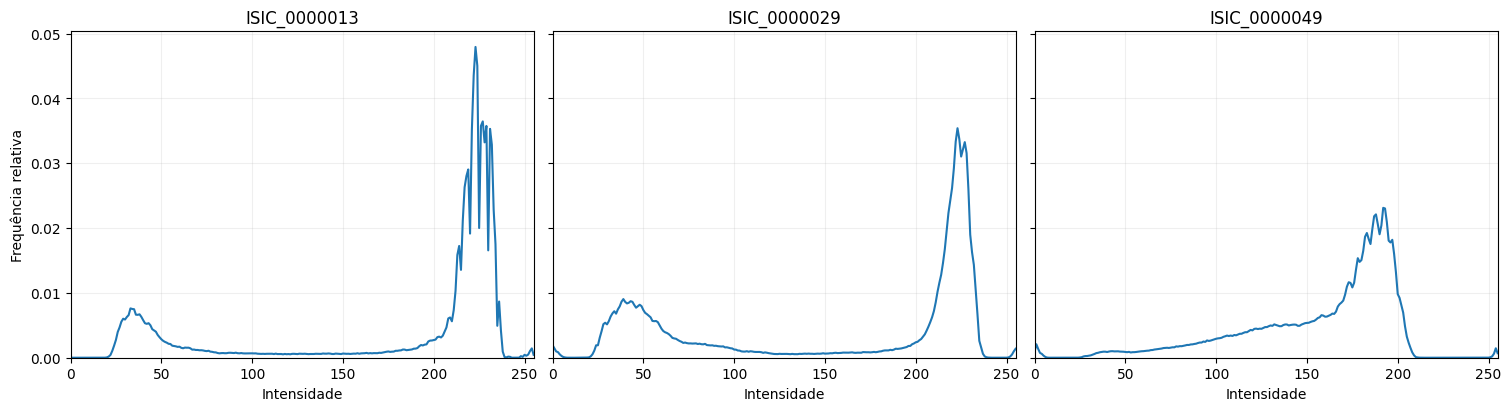

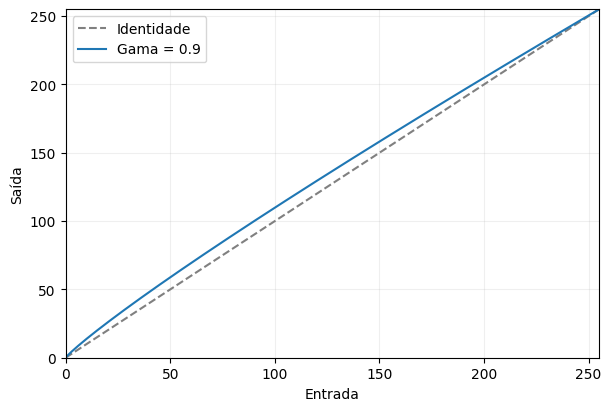

In [ ]:
# 10 — Histogramas iniciais e curva gama

figura, eixos = plt.subplots(
    1,
    len(IMAGENS),
    figsize=(15, 4),
    sharex=True,
    sharey=True,
    layout="constrained",
    squeeze=False,
)
histogramas = {}
for eixo, nome in zip(eixos[0], nomes):
    imagem = imagens_cinza[nome]
    contagens = calcular_histograma(imagem)
    frequencia = contagens / imagem.size  # Permite comparar dimensões diferentes.
    histogramas[nome] = {
        "contagens": contagens.tolist(),
        "frequencia_relativa": frequencia.tolist(),
    }
    eixo.plot(np.arange(256), frequencia)
    eixo.set(title=nome, xlabel="Intensidade", xlim=(0, 255))
    eixo.set_ylim(bottom=0)
    eixo.grid(alpha=0.2)
eixos[0, 0].set_ylabel("Frequência relativa")
salvar_figura(figura, RESULTADOS / "histogramas_iniciais.png")
salvar_json(RESULTADOS / "histogramas_iniciais.json", histogramas)

intensidades = np.arange(256, dtype=np.float64)[None, :]
figura, eixo = plt.subplots(figsize=(6, 4), layout="constrained")
eixo.plot(intensidades[0], intensidades[0], "--", color="gray", label="Identidade")
for gama in sorted({config["gama"] for config in CONFIGURACOES.values()}):
    eixo.plot(
        intensidades[0], correcao_gama(intensidades, gama)[0], label=f"Gama = {gama}"
    )
eixo.set(xlabel="Entrada", ylabel="Saída", xlim=(0, 255), ylim=(0, 255))
eixo.legend()
eixo.grid(alpha=0.2)
salvar_figura(figura, RESULTADOS / "curva_gama.png")


In [ ]:
# 11 — Degradação controlada das três referências

imagens_ruidosas = {}
mascaras_ruido = {}
registro_ruido = []
for nome in nomes:
    referencia = imagens_cinza[nome]
    degradada, mascara = adicionar_sal_pimenta(
        referencia, PROPORCAO_RUIDO, SEMENTES_RUIDO[nome]
    )
    imagens_ruidosas[nome] = degradada
    mascaras_ruido[nome] = mascara
    salvar_cinza(degradada, RUIDO / f"{nome}_ruido.png")
    # Selecionar um pixel já preto para pimenta não altera seu valor.
    registro_ruido.append(
        {
            "id": nome,
            "semente": SEMENTES_RUIDO[nome],
            "total_pixels": int(referencia.size),
            "pixels_selecionados": int(np.count_nonzero(mascara)),
            "pixels_alterados": int(np.count_nonzero(degradada != referencia)),
            "pixels_pimenta": int(np.count_nonzero(mascara == 1)),
            "pixels_sal": int(np.count_nonzero(mascara == 2)),
        }
    )

np.savez_compressed(RUIDO / "mascaras_ruido.npz", **mascaras_ruido)
salvar_json(
    DOCUMENTACAO / "parametros_ruido.json",
    {
        "tipo": "sal_e_pimenta",
        "proporcao": PROPORCAO_RUIDO,
        "gerador": "PCG64",
        "numpy_versao": np.__version__,
        "mascara": {"0": "não selecionado", "1": "pimenta", "2": "sal"},
        "imagens": registro_ruido,
    },
)
print(f"Ruído de {PROPORCAO_RUIDO:.1%} gerado para as três imagens.")


Ruído de 5.0% gerado para as três imagens.


In [ ]:
# 12 — Execução das duas configurações

experimentos = {}
registro_pipeline = []
for nome in nomes:
    entrada = imagens_ruidosas[nome]
    experimentos[nome] = {}
    for letra, parametros in CONFIGURACOES.items():
        resultado = executar_pipeline(entrada, **parametros)
        experimentos[nome][letra] = resultado
        for etapa in ("gama", "mediana", "suavizada", "final"):
            salvar_cinza(resultado[etapa], PROCESSADAS / letra / f"{nome}_{etapa}.png")
        registro_pipeline.append(
            {
                "id": nome,
                "configuracao": letra,
                "pixels_recortados_abaixo_0": resultado["recorte_abaixo"],
                "pixels_recortados_acima_255": resultado["recorte_acima"],
                "total_pixels": int(entrada.size),
            }
        )

salvar_json(
    DOCUMENTACAO / "parametros_pipeline.json",
    {
        "ordem": ["gama", "mediana", "highboost"],
        "configuracoes": CONFIGURACOES,
        "bordas": "repetição do pixel extremo",
        "intermediarios": "float64, sem quantização entre filtros",
        "imagens": registro_pipeline,
    },
)
print("Configurações A e B concluídas.")


Configurações A e B concluídas.


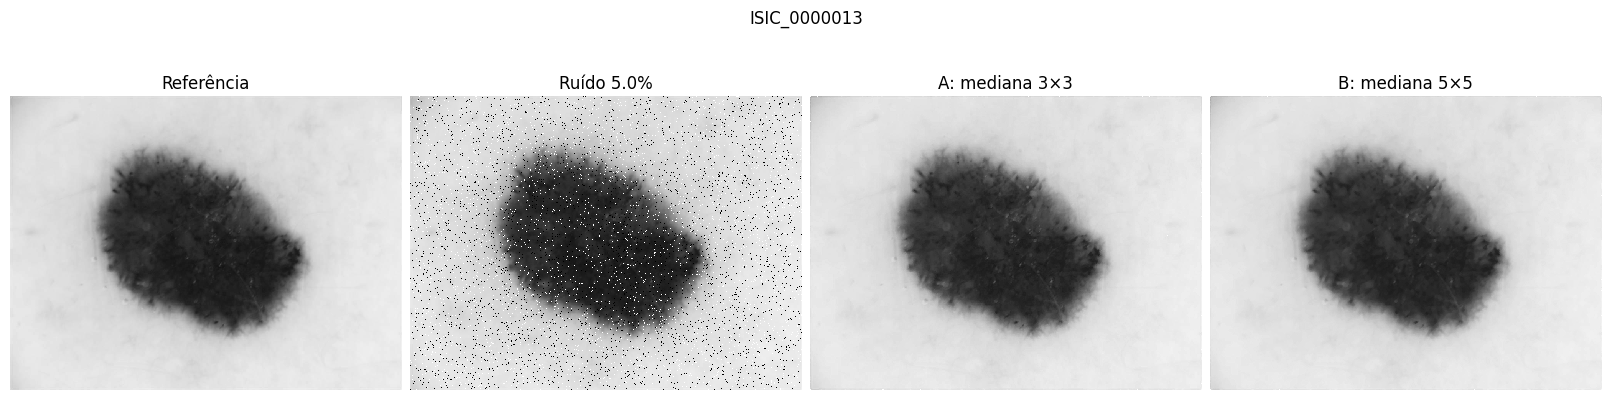

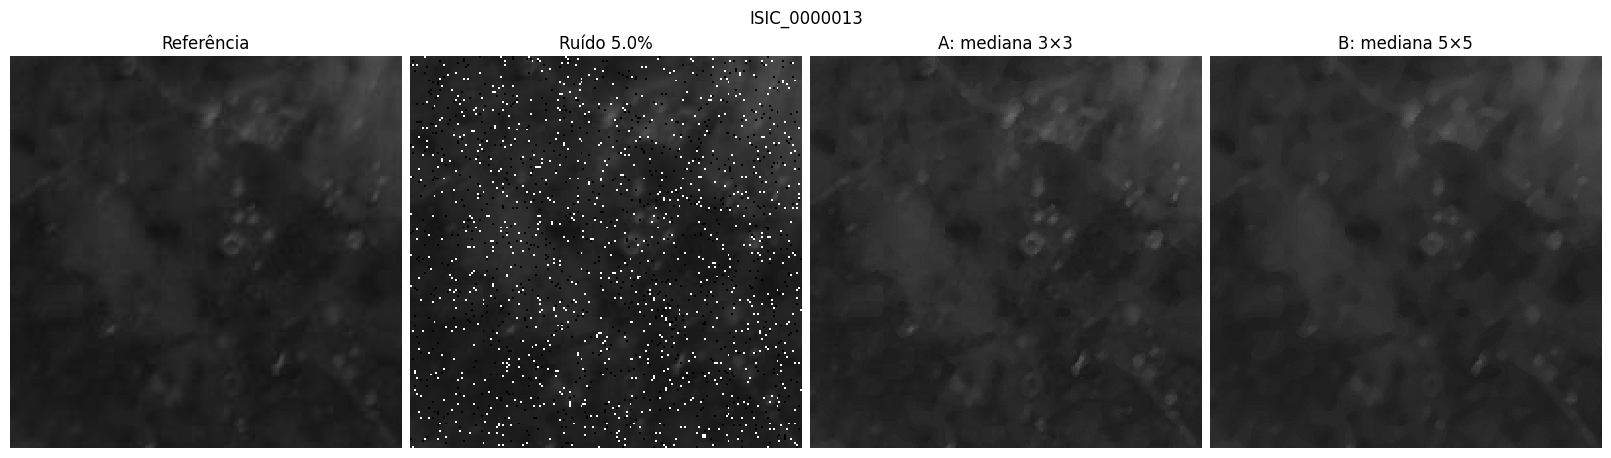

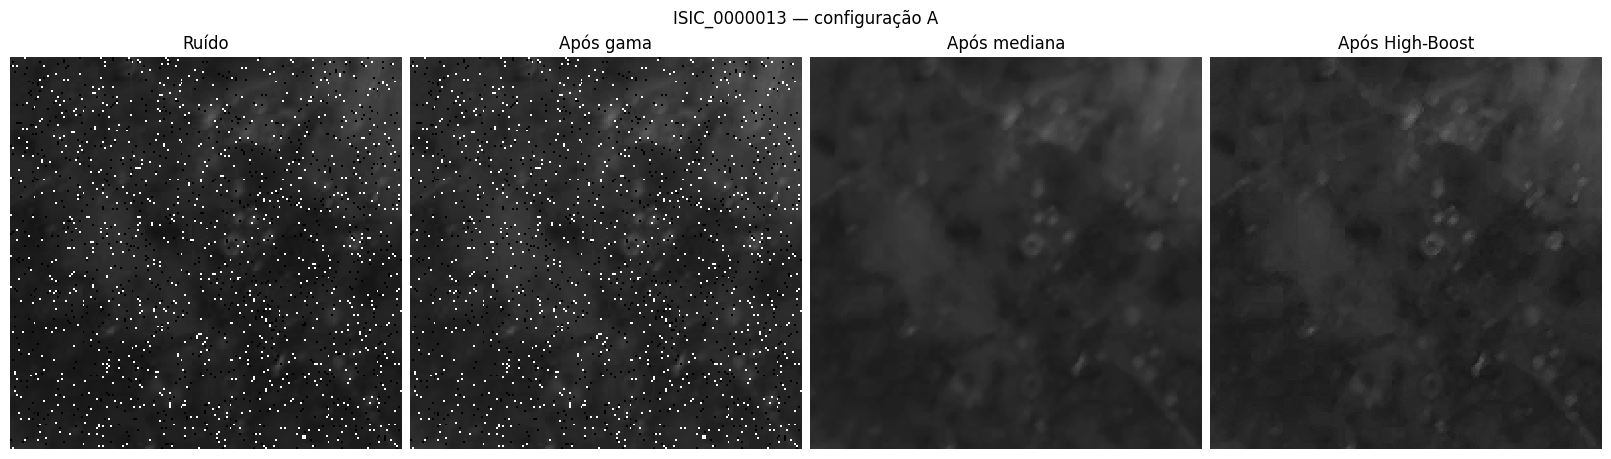

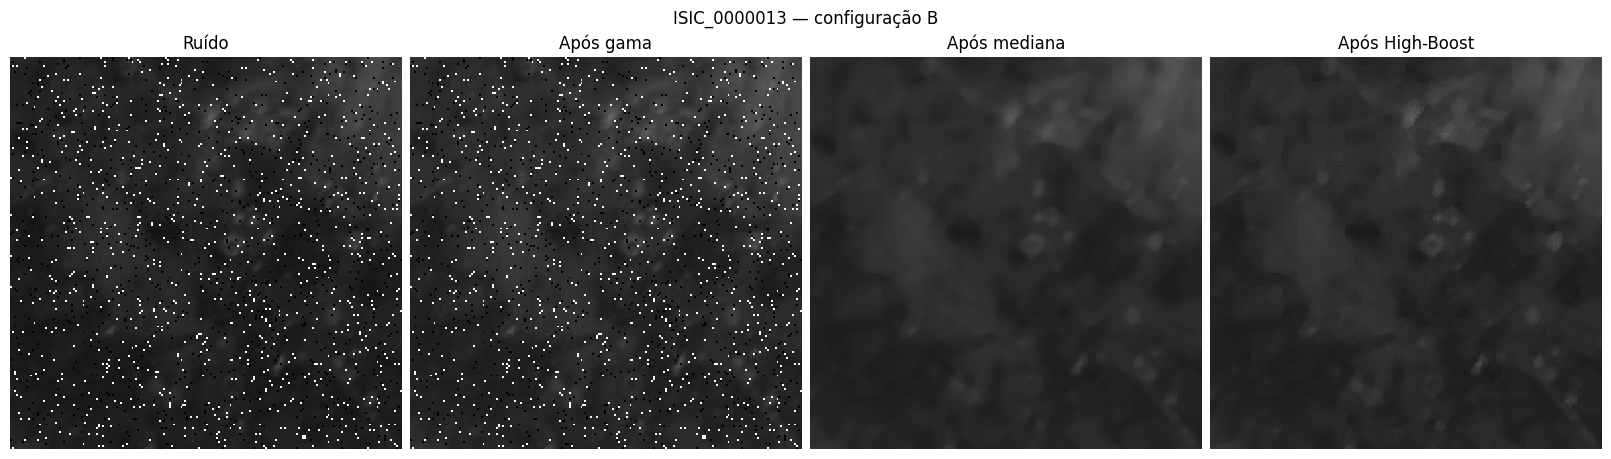

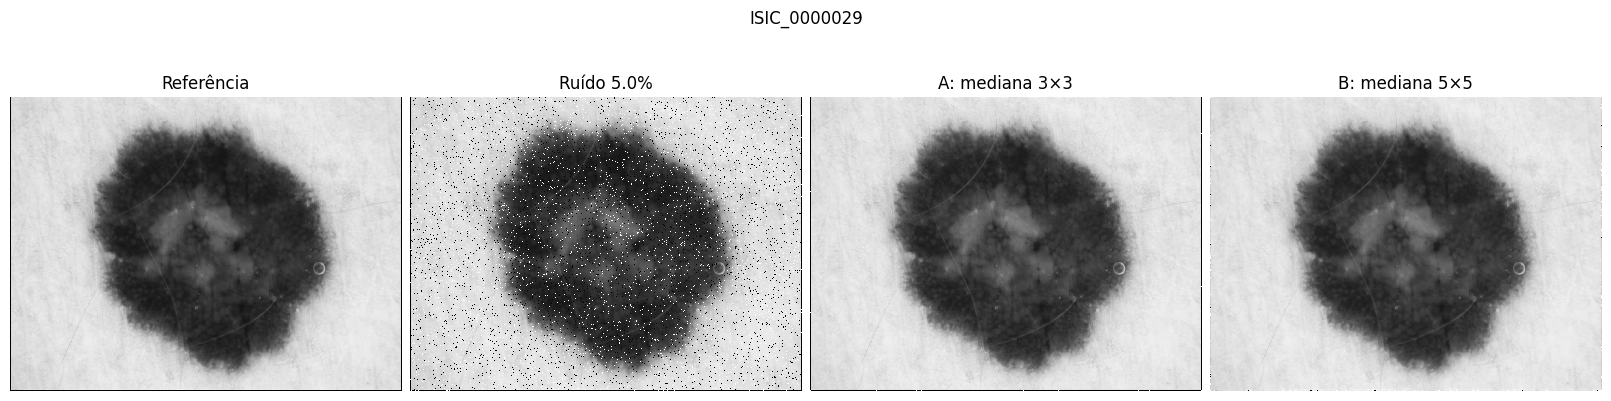

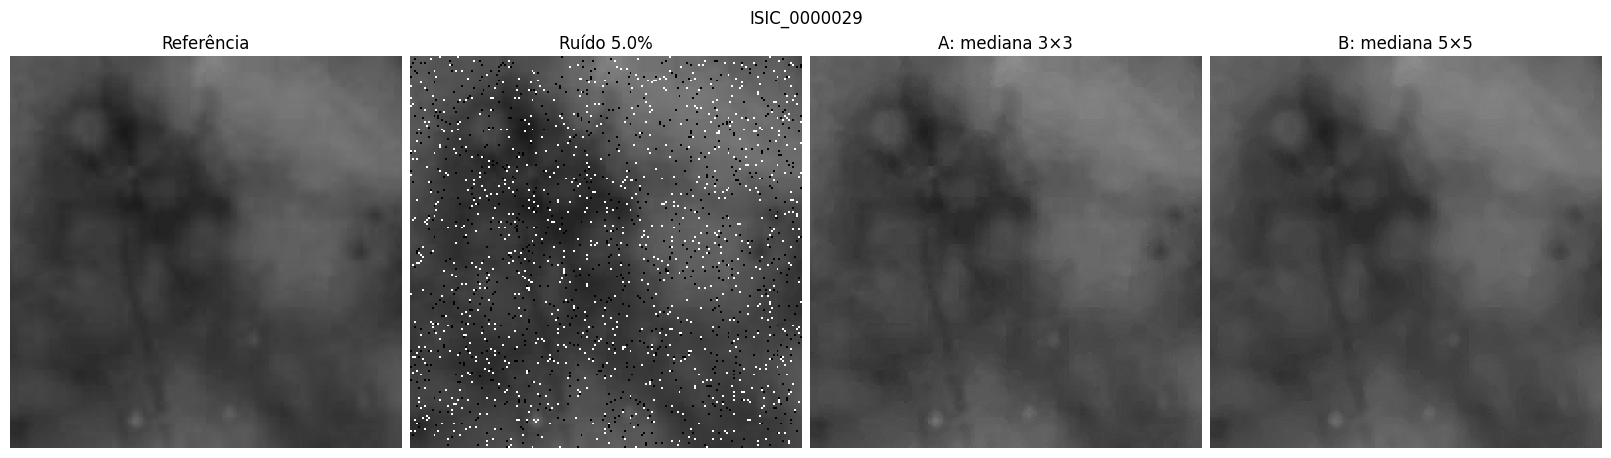

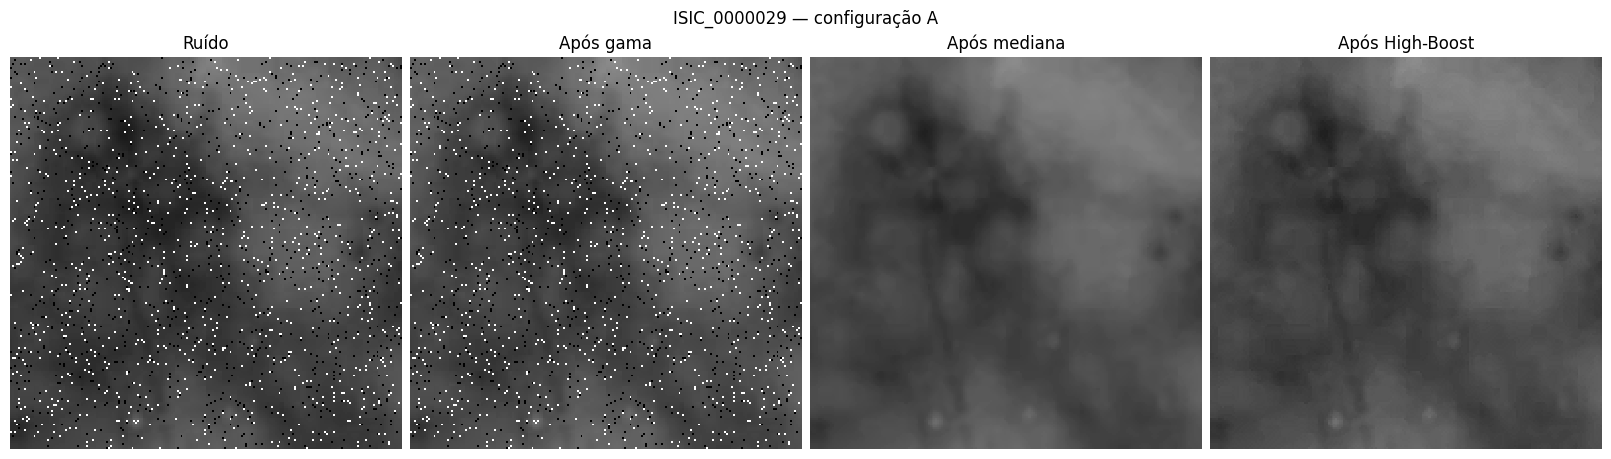

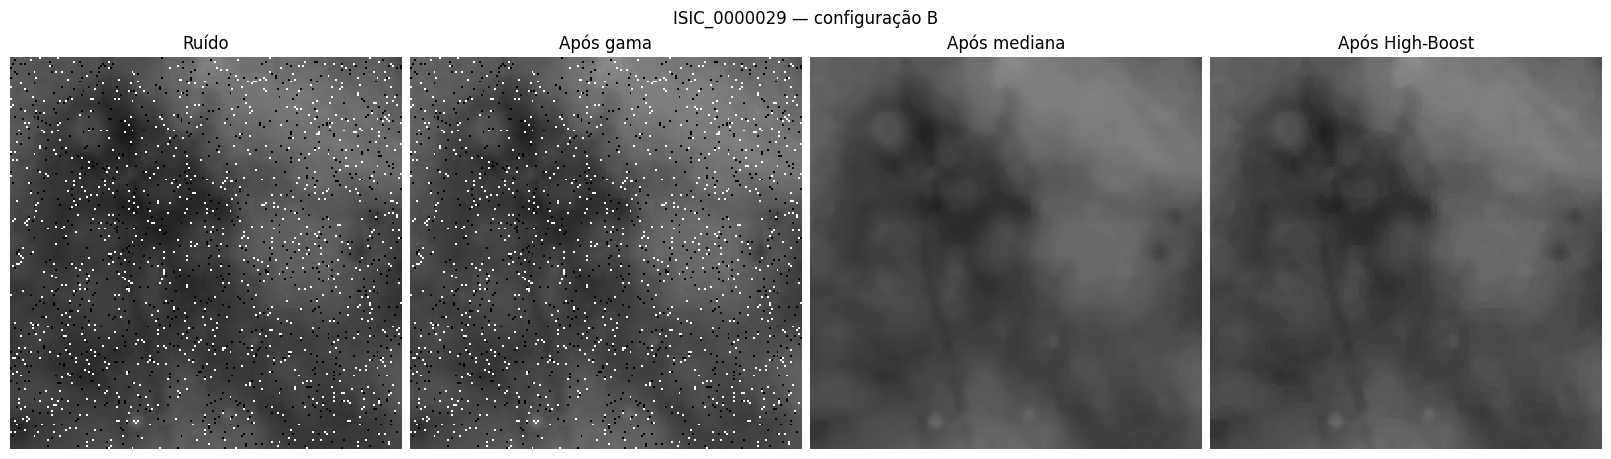

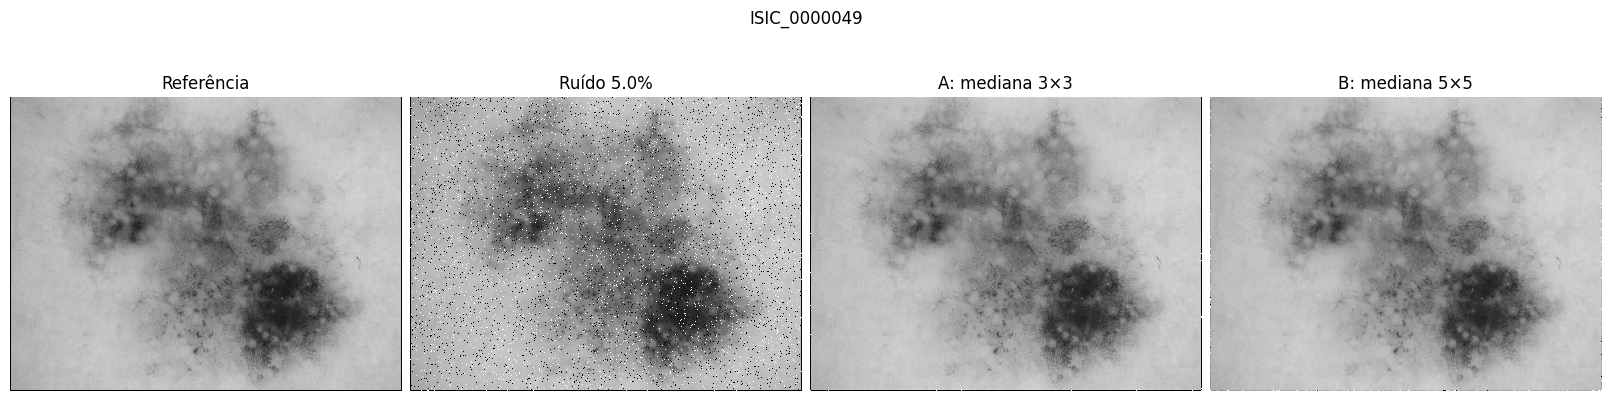

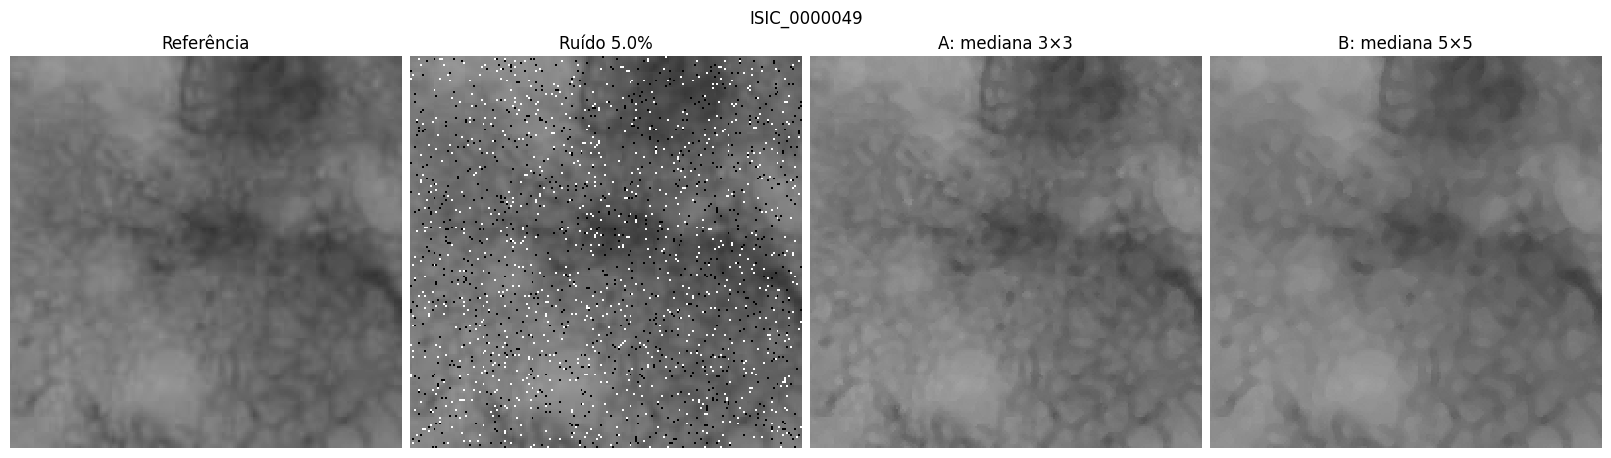

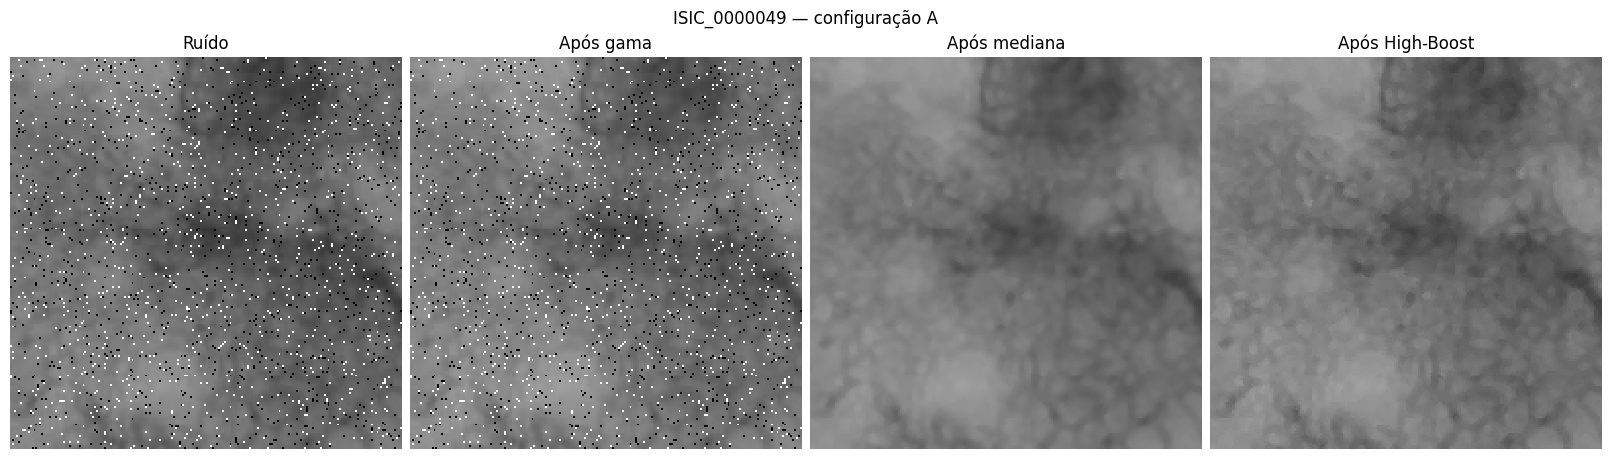

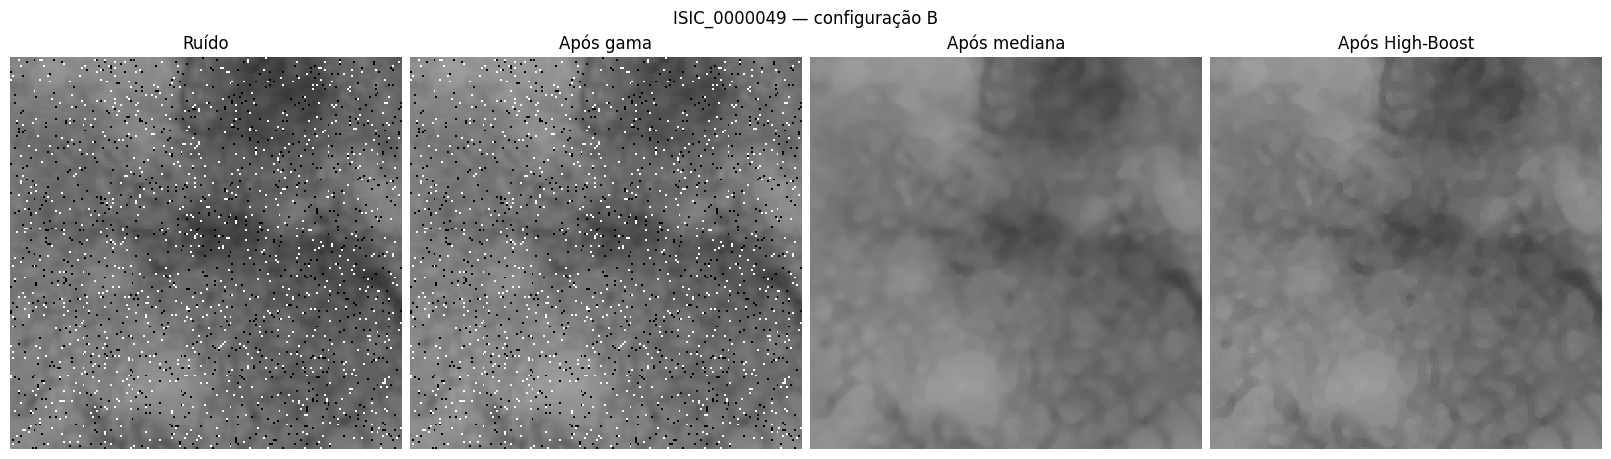

In [ ]:
# 13 — Comparações visuais completas e por etapa

for nome in nomes:
    referencia = imagens_cinza[nome]
    recorte = recorte_central(referencia)
    matrizes = [referencia, imagens_ruidosas[nome]]
    matrizes += [experimentos[nome][letra]["final"] for letra in CONFIGURACOES]
    titulos = ["Referência", f"Ruído {PROPORCAO_RUIDO:.1%}"]
    titulos += [
        f"{letra}: mediana {config['mediana']}×{config['mediana']}"
        for letra, config in CONFIGURACOES.items()
    ]
    for sufixo, area in (("comparacao_final", None), ("detalhes_final", recorte)):
        exibir_comparacao(
            matrizes, titulos, nome, RESULTADOS / f"{nome}_{sufixo}.png", area
        )
    for letra, resultado in experimentos[nome].items():
        exibir_comparacao(
            [
                imagens_ruidosas[nome],
                para_uint8(resultado["gama"]),
                para_uint8(resultado["mediana"]),
                resultado["final"],
            ],
            ["Ruído", "Após gama", "Após mediana", "Após High-Boost"],
            f"{nome} — configuração {letra}",
            RESULTADOS / f"{nome}_etapas_{letra}.png",
            recorte,
        )


In [ ]:
# 14 — Métricas por imagem e estágio
# PSNR mede erro de intensidade; SSIM compara luminância, contraste e estrutura.

linhas_metricas = []
metricas_por_imagem = {}
for nome in nomes:
    referencia = imagens_cinza[nome]
    candidatos = {"Referencia": referencia, "Ruido": imagens_ruidosas[nome]}
    for letra, resultado in experimentos[nome].items():
        # Avaliamos os mesmos pixels uint8 apresentados nos PNGs.
        for etapa in ("gama", "mediana", "final"):
            candidatos[f"{letra}_{etapa}"] = para_uint8(resultado[etapa])
    medidas = avaliar_resultados(referencia, candidatos)
    linhas_metricas.extend({"imagem": nome, **medida} for medida in medidas)
    metricas_por_imagem[nome] = {medida["etapa"]: medida for medida in medidas}

convencoes_metricas = {
    "referencia": "cinza sem ruído artificial",
    "faixa": 255,
    "pixels_avaliados": "uint8, com cálculos em float64",
    "psnr": {"formula": "10*log10(255^2/MSE)", "area": "imagem completa"},
    "ssim": {
        "janela": JANELA_SSIM,
        "sigma": SIGMA_SSIM,
        "k1": K1_SSIM,
        "k2": K2_SSIM,
        "momentos": "populacionais ponderados",
        "area": "janelas válidas",
    },
}
salvar_json(
    RESULTADOS / "metricas.json",
    {
        "convencoes": convencoes_metricas,
        "resultados": linhas_metricas,
    },
)

texto_metricas = [
    "# Métricas por imagem",
    "",
    "| Imagem | Etapa | PSNR (dB) | SSIM |",
    "|---|---|---:|---:|",
]
for medida in linhas_metricas:
    psnr_texto = "infinito" if medida["psnr_infinito"] else f"{medida['psnr_db']:.4f}"
    texto_metricas.append(
        f"| {medida['imagem']} | {medida['etapa']} | {psnr_texto} | {medida['ssim']:.6f} |"
    )
(RESULTADOS / "metricas.md").write_text("\n".join(texto_metricas), encoding="utf-8")
print("\n".join(texto_metricas))


# Métricas por imagem

| Imagem | Etapa | PSNR (dB) | SSIM |
|---|---|---:|---:|
| ISIC_0000013 | Referencia | infinito | 1.000000 |
| ISIC_0000013 | Ruido | 17.2703 | 0.221944 |
| ISIC_0000013 | A_gama | 17.1849 | 0.222119 |
| ISIC_0000013 | A_mediana | 33.9465 | 0.991689 |
| ISIC_0000013 | A_final | 33.8702 | 0.986886 |
| ISIC_0000013 | B_gama | 17.1849 | 0.222119 |
| ISIC_0000013 | B_mediana | 33.8686 | 0.988650 |
| ISIC_0000013 | B_final | 33.8440 | 0.984979 |
| ISIC_0000029 | Referencia | infinito | 1.000000 |
| ISIC_0000029 | Ruido | 17.3994 | 0.226740 |
| ISIC_0000029 | A_gama | 17.2741 | 0.224999 |
| ISIC_0000029 | A_mediana | 30.7299 | 0.987828 |
| ISIC_0000029 | A_final | 30.3029 | 0.981720 |
| ISIC_0000029 | B_gama | 17.2741 | 0.224999 |
| ISIC_0000029 | B_mediana | 22.5933 | 0.974191 |
| ISIC_0000029 | B_final | 22.6510 | 0.969936 |
| ISIC_0000049 | Referencia | infinito | 1.000000 |
| ISIC_0000049 | Ruido | 18.3778 | 0.210798 |
| ISIC_0000049 | A_gama | 18.1494 | 0.211508 

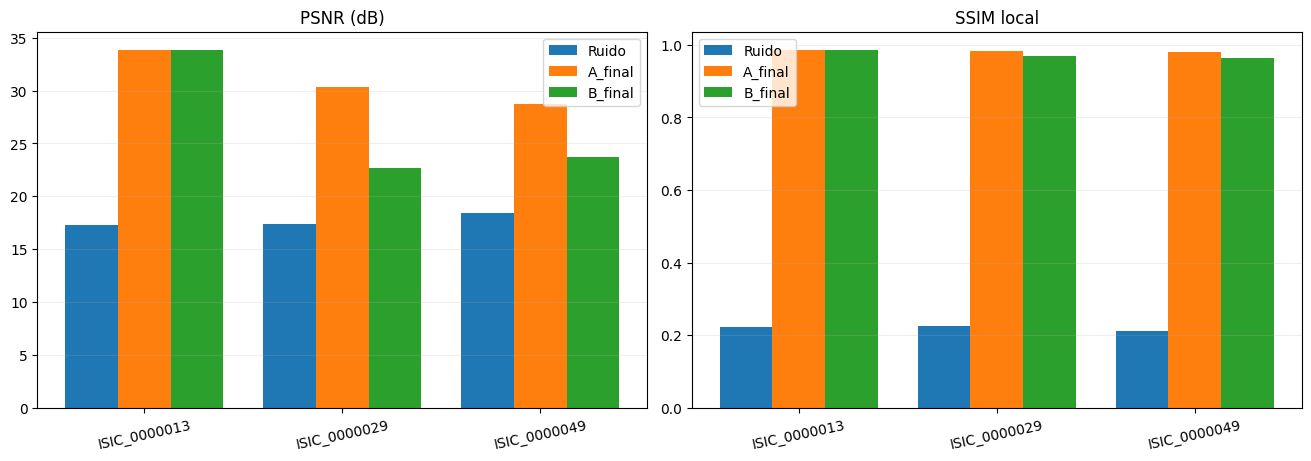

In [ ]:
# 15 — Gráfico comparativo das métricas

figura, eixos = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
posicoes = np.arange(len(nomes))
etapas = ["Ruido"] + [f"{letra}_final" for letra in CONFIGURACOES]
largura_barra = 0.8 / len(etapas)
for indice, etapa in enumerate(etapas):
    deslocamento = (indice - (len(etapas) - 1) / 2) * largura_barra
    for eixo, chave in zip(eixos, ("psnr_db", "ssim")):
        valores = [metricas_por_imagem[nome][etapa][chave] for nome in nomes]
        eixo.bar(posicoes + deslocamento, valores, width=largura_barra, label=etapa)
for eixo, titulo in zip(eixos, ("PSNR (dB)", "SSIM local")):
    eixo.set_xticks(posicoes, nomes, rotation=12)
    eixo.set_title(titulo)
    eixo.grid(axis="y", alpha=0.2)
    eixo.legend()
salvar_figura(figura, RESULTADOS / "comparacao_metricas.png")


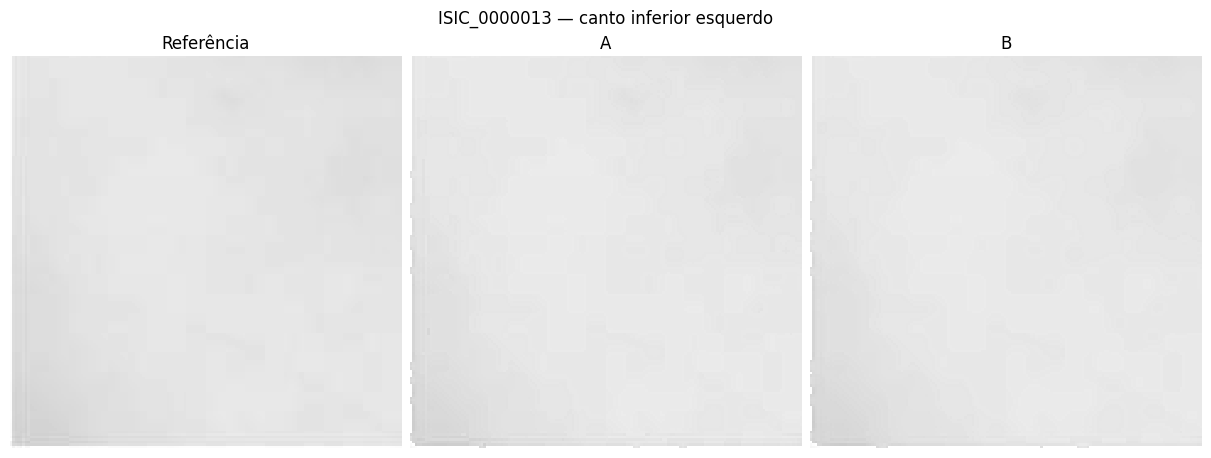

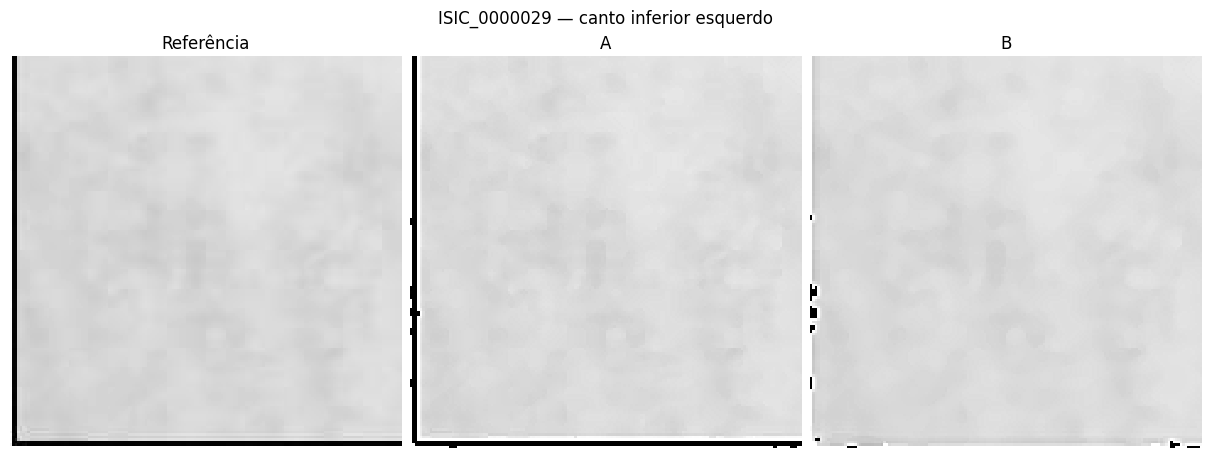

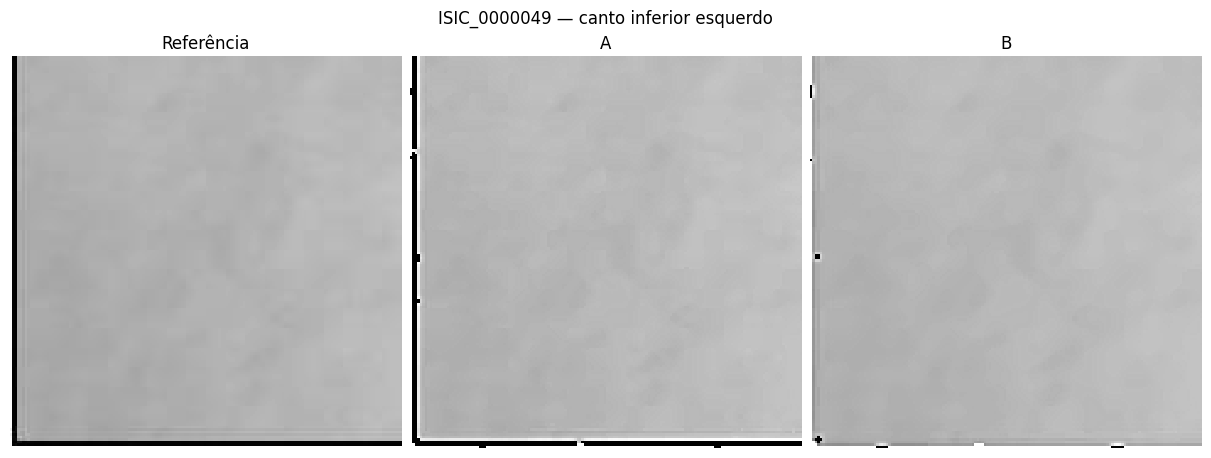

ISIC_0000013 A: 2.90% do erro quadrático está na faixa externa.
ISIC_0000013 B: 2.64% do erro quadrático está na faixa externa.
ISIC_0000029 A: 38.59% do erro quadrático está na faixa externa.
ISIC_0000029 B: 89.35% do erro quadrático está na faixa externa.
ISIC_0000049 A: 36.12% do erro quadrático está na faixa externa.
ISIC_0000049 B: 79.80% do erro quadrático está na faixa externa.


In [ ]:
# 16 — Influência das bordas: diagnóstico complementar do PSNR
# A faixa externa pode concentrar muito erro, embora contenha poucos pixels.
# O PSNR principal continua usando a imagem inteira.

diagnostico_bordas = []
for nome in nomes:
    referencia = imagens_cinza[nome]
    if FAIXA_BORDA < 1 or 2 * FAIXA_BORDA >= min(referencia.shape):
        raise ValueError("A faixa de borda deve deixar um interior não vazio.")
    interior = (slice(FAIXA_BORDA, -FAIXA_BORDA),) * 2
    for letra, resultado in experimentos[nome].items():
        final = resultado["final"]
        erro2 = (referencia.astype(np.float64) - final.astype(np.float64)) ** 2
        total = float(erro2.sum())
        soma_borda = total - float(erro2[interior].sum())
        psnr_interior = psnr(referencia[interior], final[interior])
        diagnostico_bordas.append(
            {
                "imagem": nome,
                "configuracao": letra,
                "percentual_pixels_faixa_externa": 100
                * (1 - erro2[interior].size / erro2.size),
                "percentual_erro_quadratico_faixa_externa": (
                    100 * soma_borda / total if total else 0
                ),
                "psnr_principal_db": metricas_por_imagem[nome][f"{letra}_final"][
                    "psnr_db"
                ],
                "psnr_interior_diagnostico_db": (
                    None if np.isinf(psnr_interior) else psnr_interior
                ),
                "psnr_interior_infinito": bool(np.isinf(psnr_interior)),
            }
        )
    exibir_comparacao(
        [referencia] + [experimentos[nome][letra]["final"] for letra in CONFIGURACOES],
        ["Referência"] + list(CONFIGURACOES),
        f"{nome} — canto inferior esquerdo",
        RESULTADOS / f"{nome}_detalhes_borda.png",
        (slice(-160, None), slice(0, 160)),
    )

salvar_json(
    RESULTADOS / "diagnostico_bordas.json",
    {
        "faixa_px": FAIXA_BORDA,
        "resultados": diagnostico_bordas,
    },
)
for medida in diagnostico_bordas:
    print(
        f"{medida['imagem']} {medida['configuracao']}: "
        f"{medida['percentual_erro_quadratico_faixa_externa']:.2f}% "
        "do erro quadrático está na faixa externa."
    )


In [ ]:
# 17 — Discussão gerada a partir dos resultados atuais
# Critério: maior SSIM final; PSNR e inspeção visual complementam a escolha.

discussao = ["# Discussão dos resultados", ""]
for nome in nomes:
    tabela = metricas_por_imagem[nome]
    vencedora = max(CONFIGURACOES, key=lambda letra: tabela[f"{letra}_final"]["ssim"])
    por_psnr = max(
        CONFIGURACOES,
        key=lambda letra: (
            float("inf")
            if tabela[f"{letra}_final"]["psnr_infinito"]
            else tabela[f"{letra}_final"]["psnr_db"]
        ),
    )
    discussao += [
        f"## {nome}",
        "",
        f"Escolha pelo SSIM: {vencedora}. Escolha pelo PSNR: {por_psnr}.",
    ]
    for letra, resultado in experimentos[nome].items():
        final = tabela[f"{letra}_final"]
        mediana = tabela[f"{letra}_mediana"]
        percentual_recorte = (
            100
            * (resultado["recorte_abaixo"] + resultado["recorte_acima"])
            / imagens_cinza[nome].size
        )
        discussao.append(
            f"{letra}: SSIM após mediana = {mediana['ssim']:.6f}; "
            f"após High-Boost = {final['ssim']:.6f}. "
            f"Valores limitados a 0–255: {percentual_recorte:.4f}% dos pixels."
        )
    discussao.append("")

discussao += [
    "## Interpretação e limitações",
    "",
    "As métricas medem fidelidade à referência; não comprovam qualidade diagnóstica.",
    "Gama altera intensidades; High-Boost pode intensificar resíduos de ruído e artefatos.",
    "A mediana maior pode apagar estruturas finas. Compare os mesmos recortes de A e B.",
    "Confira a contribuição da moldura externa antes de interpretar diferenças de PSNR.",
    "As primeiras janelas válidas do SSIM ainda incluem pixels da borda original.",
    "A conversão para cinza descarta informações de cor; os originais RGB são preservados.",
    "Três imagens e uma realização de ruído por imagem não permitem generalizar o vencedor.",
]
(DOCUMENTACAO / "discussao_resultados.md").write_text(
    "\n".join(discussao), encoding="utf-8"
)
print("\n".join(discussao))

# Observações visuais da configuração padrão, a revisar se os parâmetros mudarem:
# ISIC_0000013: A preserva um pouco mais de textura; a região central segue escura.
# ISIC_0000029: pelos e o círculo permanecem; B altera mais a moldura externa.
# ISIC_0000049: B suaviza pequenas linhas; High-Boost não recupera detalhes removidos.


# Discussão dos resultados

## ISIC_0000013

Escolha pelo SSIM: A. Escolha pelo PSNR: A.
A: SSIM após mediana = 0.991689; após High-Boost = 0.986886. Valores limitados a 0–255: 0.3492% dos pixels.
B: SSIM após mediana = 0.988650; após High-Boost = 0.984979. Valores limitados a 0–255: 0.3314% dos pixels.

## ISIC_0000029

Escolha pelo SSIM: A. Escolha pelo PSNR: A.
A: SSIM após mediana = 0.987828; após High-Boost = 0.981720. Valores limitados a 0–255: 1.2576% dos pixels.
B: SSIM após mediana = 0.974191; após High-Boost = 0.969936. Valores limitados a 0–255: 0.3612% dos pixels.

## ISIC_0000049

Escolha pelo SSIM: A. Escolha pelo PSNR: A.
A: SSIM após mediana = 0.986881; após High-Boost = 0.979411. Valores limitados a 0–255: 1.1108% dos pixels.
B: SSIM após mediana = 0.965292; após High-Boost = 0.963134. Valores limitados a 0–255: 0.3273% dos pixels.

## Interpretação e limitações

As métricas medem fidelidade à referência; não comprovam qualidade diagnóstica.
Gama altera intensidades; H

In [ ]:
# 18 — Demonstração opcional com outra imagem


def processar_imagem_extra(caminho, pasta_saida=None):
    caminho = Path(caminho)
    rgb = carregar_rgb(caminho)
    referencia = rgb_para_cinza(rgb)
    if min(referencia.shape) < JANELA_SSIM:
        raise ValueError(f"Use pelo menos {JANELA_SSIM} pixels em cada dimensão.")
    pasta = (
        Path(pasta_saida) if pasta_saida is not None else BASE / "extras" / caminho.stem
    )
    pasta.mkdir(parents=True, exist_ok=True)
    Image.fromarray(rgb).save(pasta / "entrada_rgb.png")
    salvar_cinza(referencia, pasta / "referencia_cinza.png")
    degradada, _ = adicionar_sal_pimenta(referencia, PROPORCAO_RUIDO, 20260924)
    saidas = {"Ruido": degradada}
    saidas.update(
        {
            letra: executar_pipeline(degradada, **parametros)["final"]
            for letra, parametros in CONFIGURACOES.items()
        }
    )
    for letra, matriz in saidas.items():
        salvar_cinza(matriz, pasta / f"{letra}.png")
    medidas = avaliar_resultados(referencia, saidas)
    salvar_json(
        pasta / "experimento.json",
        {
            "arquivo_entrada": caminho.name,
            "configuracoes": CONFIGURACOES,
            "ruido_proporcao": PROPORCAO_RUIDO,
            "semente": 20260924,
            "convencoes_metricas": convencoes_metricas,
            "metricas": medidas,
        },
    )
    exibir_comparacao(
        [referencia] + list(saidas.values()),
        ["Referência"] + list(saidas),
        caminho.name,
        pasta / "comparacao.png",
    )
    print("Demonstração salva em:", pasta)
    return medidas


# No Colab, envie a imagem pelo painel de arquivos e informe o caminho abaixo.
CAMINHO_IMAGEM_EXTRA = globals().get("IMAGEM_EXTRA")  # Ex.: "/content/teste.jpg"
if CAMINHO_IMAGEM_EXTRA is not None:
    print(processar_imagem_extra(CAMINHO_IMAGEM_EXTRA))


In [ ]:
# 19 — Backup opcional dos dados e resultados
# O ZIP não inclui o notebook: salve também o .ipynb pelo menu Arquivo do Colab.

if EXPORTAR_BACKUP:
    arquivo_zip = shutil.make_archive(
        str(BASE.parent / "backup_projeto_m1"), "zip", root_dir=BASE
    )
    try:
        from google.colab import files
    except ImportError:
        print("Backup criado em:", arquivo_zip)
    else:
        files.download(arquivo_zip)
